In [1]:
import jax.numpy as np
import numpy as onp
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from gwfast.gwfastGlobals import MTSUN_SI

plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=12)

from gwfast.lensing_utils_alt import \
    get_agn_lens_angles, PML_time_delay_magnification

# %matplotlib widget

In [2]:
n = 1000
shape = (n, n)
events = {
    'Mc':np.full(shape, 30), 'eta':np.full(shape, 0.24), 
    'chi1z':np.full(shape, 0.3), 'chi2z':np.full(shape, 0.5), 
    'tcoal':np.full(shape, 0), 'phase':np.full(shape, 2), 
    'R_orbit':np.full(shape, 100), 'M_lz':np.full(shape, 1e4), 'src_pos':np.full(shape, 0.5),
    'iota':np.full(shape, 0.99*np.pi/2), 'psi':np.full(shape, 4), 
    'dL':np.full(shape, 1), 'theta':np.full(shape, 1.87), 'phi':np.full(shape, 2.66), 
}
events = {key: val.astype(np.float64) for key, val in events.items()}

src_pos_array = np.geomspace(0.02, 0.99, n)
M_lz_array = np.geomspace(1e4, 1e6, n)
M_lz_array = np.geomspace(3e3, 7e6, n)

src_pos_mesh, M_lz_mesh = np.meshgrid(src_pos_array, M_lz_array, indexing='xy')
events['src_pos'] = src_pos_mesh
events['M_lz'] = M_lz_mesh

In [ ]:
theta_E, beta, lens_src_mass = get_agn_lens_angles(
        events['M_lz'], events['R_orbit'], 
        events['src_pos'], events['dL'],
    )
time_delay, _, _ = PML_time_delay_magnification(beta_src=beta, theta_E=theta_E)
time_delay_SI = - time_delay * lens_src_mass * MTSUN_SI

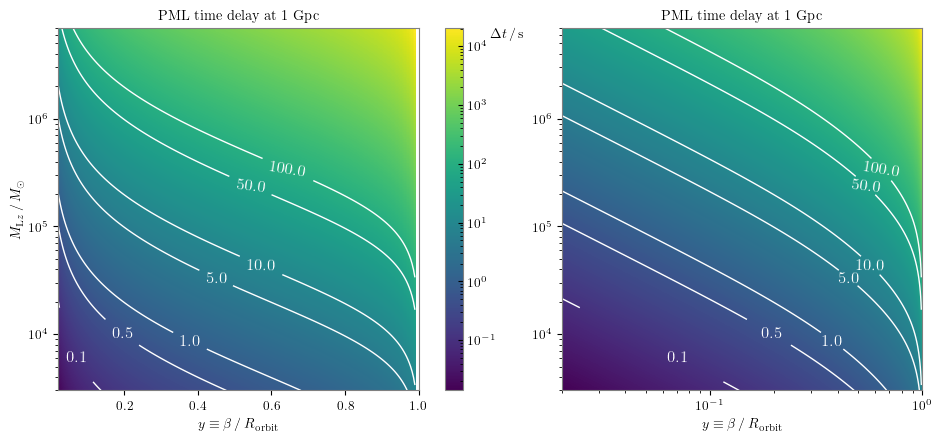

In [4]:
time_delay_levels = [0.1, 0.5, 1, 5, 10, 50, 100]

# Hand-picked positions for nice label locations
nice_positions = [
    [0.07, 5950],
    [0.195, 10000],
    [0.379, 8790],
    [0.45, 33805],
    [0.572, 44640],
    [0.543, 236600],
    [0.645, 347670]
]

fig, axes = plt.subplots(1, 2, figsize=(9.3, 4.3), constrained_layout=True)
for ax in axes:
    im = ax.pcolormesh(src_pos_array, M_lz_array, time_delay_SI, 
                        norm=LogNorm()
                        )
    contour = ax.contour(src_pos_array, M_lz_array, time_delay_SI, 
                            levels=time_delay_levels, colors='white')
    ax.clabel(contour, inline=True, fmt='%1.1f', colors='white', manual=nice_positions)
    ax.set_yscale('log')
    ax.set_xlabel(r'$y \equiv \beta\,/\,R_{\rm orbit}$')
    ax.set_title(r'PML time delay at 1 Gpc')
    ax.tick_params(axis='both', which='both', direction='out')
    ax.set_xlim(0.02, 1)

axes[1].set_xscale('log')

axes[0].set_ylabel(r'$M_{{\rm L}z}\,/\,M_{\odot}$')
cbar = fig.colorbar(im, ax=axes[0])
cbar.set_label(r'$\Delta t\,/\,{\rm s}$', labelpad=20, loc='top', rotation=0)

# What if we do it in units of Einstein radius?

In [5]:
PML_time_delay_magnification?

Signature: PML_time_delay_magnification(beta_src, theta_E=1)
Docstring:
Time delay is simplified from https://inspirehep.net/literature/1862768,
Eq. (3.13), with θ_± = (β ± √ (β² + 4)) / 2, for β measured in units of θ_E.

t(+) - t(-) = -β √(4 +  β²) + 2 ln(θ(-) / θ(+))

The magnifications are taken from Eq. (3.8) directly.

Parameters:
----------
beta_src: float / array-like
    The source position angle.
    If theta_E is not given, it is assumed to be in unit of theta_E.
    Otherwise, it should have the same unit as theta_E (radian, R_Sch, etc).
theta_E: float / array-like
    The Einstein radius (angle), it acts as the scale of for beta_src.
    It can have any units, as long as it being consistent with beta_src.

Returns:
----------
delta_t: float / array-like
    The time delay between the "+" and "-" images, in geometric time.
    (Need to multiply by GM/c^3 to get SI unit.)
mag_p, mag_m: float / array-like
    The magnification of the "+" and "-" images respectively.
File:    

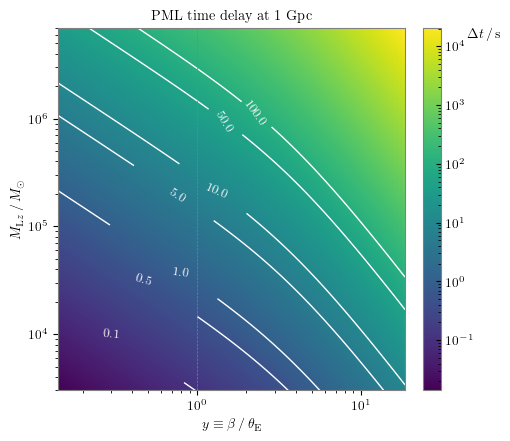

In [11]:
time_delay_levels = [0.1, 0.5, 1, 5, 10, 50, 100]

# Hand-picked positions for nice label locations
nice_positions = [
    [0.30, 9990],
    [0.47, 31000],
    [0.80, 38400],
    [0.75, 182600],
    [1.34, 207679],
    [1.46, 947000],
    [2.32, 1123600]
]

y_array = beta / theta_E

fig, ax = plt.subplots(1, 1, figsize=(5, 4.3), constrained_layout=True)

im = ax.scatter(y_array, M_lz_mesh, c=time_delay_SI, 
                    norm=LogNorm()
                    )
contour = ax.contour(y_array, M_lz_mesh, time_delay_SI, 
                        levels=time_delay_levels, colors='white')
ax.clabel(contour, inline=True, fmt='%1.1f', colors='white', 
          inline_spacing=3, fontsize=9, manual=nice_positions)
ax.set_yscale('log')
ax.set_xlabel(r'$y \equiv \beta\,/\,\theta_{\rm E}$')
ax.set_title(r'PML time delay at 1 Gpc')
ax.tick_params(axis='both', which='both', direction='out')

ax.axvline(1, color='grey', linestyle='--', linewidth=0.5)

ax.set_xscale('log')

ax.set_ylabel(r'$M_{{\rm L}z}\,/\,M_{\odot}$')
cbar = fig.colorbar(im, ax=ax)
cbar.set_label(r'$\Delta t\,/\,{\rm s}$', labelpad=20, loc='top', rotation=0)

In [7]:
MTSUN_SI

4.925491025543576e-06

In [45]:
# Find the actual lens source mass at M_lz = 1e6 solar masses
indices = np.argmin(np.abs(M_lz_mesh - 1e6))
np.unique(lens_src_mass.flatten()[indices]) / 1e6

Array([0.83271844], dtype=float64)

okay, that's a bit smaller, which should fine...

In [44]:
indices = onp.argmin(np.abs(lens_src_mass - 1e6))
np.unique(M_lz_mesh.flatten()[indices]) / 1e6

Array([1.20171647], dtype=float64)